# 2 · Autoencoders: AE y DAE

**Hipótesis:** un autoencoder entrenado solo con campañas normales reconstruye mal
las anómalas; el **error de reconstrucción** es el score.

Acá entrenamos **AE** (autoencoder) y **DAE** (denoising, reconstruye limpio desde input
corrupto), multi-seed y a la vista. Al final probamos correr **IForest y One-Class SVM
sobre el espacio latente** del AE (la receta "deep representation + shallow detector").

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


## 2.1 · Autoencoder (AE)
Encoder comprime las 54 features a un latente de 16, decoder reconstruye, score = MSE.
Entrenamos **una semilla por vuelta** y guardamos las métricas — el loop está a la vista:

In [3]:
filas_ae = []
for seed in SEEDS:
    ae = AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=300, patience=30,
                    random_state=seed).fit(ds.X_train)          # entrena de verdad
    scores = ae.score_samples(ds.X_test)                        # error de reconstrucción
    filas_ae.append(lab.metrics(scores, ds.y_test))
print("AE (soja, media±std entre semillas):")
lab.mean_std(filas_ae)

AE (soja, media±std entre semillas):


pr_auc              0.364±0.065
roc_auc             0.624±0.088
prec_at_k           0.382±0.084
recall_at_contam    0.155±0.050
dtype: str

La curva de loss del último AE (entrena bien; el problema no es el fit):

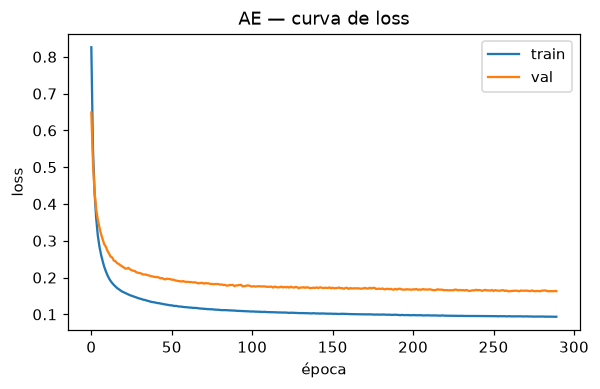

In [4]:
h = pd.DataFrame(ae.history_)
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(h["epoch"], h["train_loss"], label="train"); ax.plot(h["epoch"], h["val_loss"], label="val")
ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.legend(); ax.set_title("AE — curva de loss"); plt.show()

## 2.2 · Denoising AE (DAE)
Se corrompe el input y se entrena a reconstruir el limpio → representación más robusta al
ruido:

In [5]:
filas_dae = []
for seed in SEEDS:
    dae = DenoisingAEDetector(hidden_dims=(64,32), latent_dim=16, corruption=0.1,
                              noise_type="salt_pepper", max_epochs=300, patience=30,
                              random_state=seed).fit(ds.X_train)
    filas_dae.append(lab.metrics(dae.score_samples(ds.X_test), ds.y_test))
print("DAE (soja, media±std):")
lab.mean_std(filas_dae)

DAE (soja, media±std):


pr_auc              0.354±0.036
roc_auc             0.610±0.035
prec_at_k           0.361±0.043
recall_at_contam    0.159±0.026
dtype: str

### AE vs DAE vs TODOS los baselines
Contra el conjunto completo de baselines del nb 1 (estadísticos y de modelos), no solo el IForest:

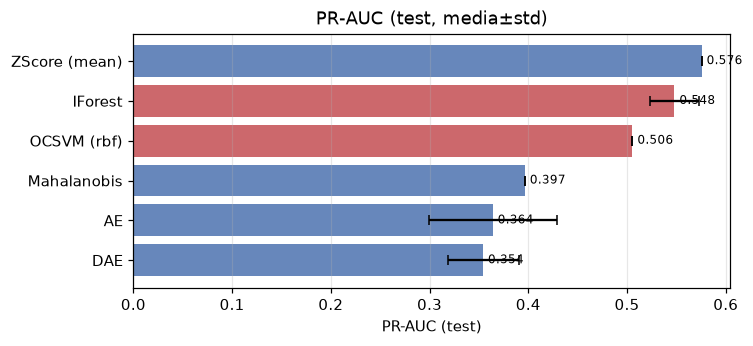

,pr_auc,roc_auc
ZScore (mean),0.576±0.000,0.714±0.000
IForest,0.548±0.025,0.697±0.018
OCSVM (rbf),0.506±0.000,0.700±0.000
Mahalanobis,0.397±0.000,0.659±0.000
AE,0.364±0.065,0.624±0.088
DAE,0.354±0.036,0.610±0.035


In [6]:
resumen = {
    "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                random_state=s).fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS[:3]],
    "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
    "AE": filas_ae, "DAE": filas_dae,
}
lab.plot_leaderboard(lab.leaderboard(resumen)); plt.show()
lab.tabla(resumen)

Ambos quedan por debajo del baseline: el **error de reconstrucción con MSE no alcanza**.
El problema no es la arquitectura (se probaron 24 variantes en la exploración, todas
en un rango estrecho) sino el *score* — lo resolvemos con el VAE en el nb 3.

## 2.3 · IForest y OCSVM sobre el latente del AE
Idea de la literatura: usar el AE solo para **comprimir** y correr un detector shallow en
el espacio latente (16 dim), donde el ruido de features redundantes ya se descartó.
Entrenamos un AE, sacamos el latente con `.encode()`, y corremos los detectores ahí:

In [7]:
ae = AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=300, patience=30,
                random_state=42).fit(ds.X_train)
Ztr, Zte = ae.encode(ds.X_train), ae.encode(ds.X_test)   # espacio latente (16 dim)
print("latente:", Ztr.shape)
latente = {
    "IForest sobre latente": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                              random_state=s).fit(Ztr).score_samples(Zte), ds.y_test) for s in SEEDS[:3]],
    "OCSVM-RBF sobre latente": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                .fit(Ztr).score_samples(Zte), ds.y_test)],
}
lab.tabla(latente)

latente: (6143, 16)


,pr_auc,roc_auc
OCSVM-RBF sobre latente,0.397±0.000,0.610±0.000
IForest sobre latente,0.273±0.016,0.501±0.013


**No mejora sobre el baseline.** El bottleneck del AE (entrenado por MSE) destruye la
estructura que el detector necesita: comprimir a un latente optimizado para reconstruir no
preserva la señal de anomalía. Guardamos la idea — con el VAE (nb 3) el latente es mejor,
pero ni así supera al score `recon_prob` directo.

**Conclusión:** AE/DAE con MSE no alcanzan, ni directo ni vía latente. **El problema es el
score, no la arquitectura** → nb 3.